TP     -                              PT   -                                Informatique commune

# Base de données (BDD) - TP2 - Enoncé

**Objectifs du TP2:** 
- La clause where 
- Les opérateurs ensemblistes 
- Règles d'intégrité associés aux liens entre les relations: clés étrangères et contraintes de référence
- La jointure

# 1. La clause where

## 1.1 Définition

La clause WHERE permet :
- de spécifier les t-uplets à sélectionner dans une relation ou dans le produit cartésien de plusieurs relations,
- de définir le critère de sélection : un prédicat qui est évalué pour chaque t-uplet.

**Syntaxe de la clause WHERE **:

WHERE "critère de sélection"

Nous gardons la même base de données cinémas que nous avons utilisés dans le TP1. Rappelons le schéma relationnel:
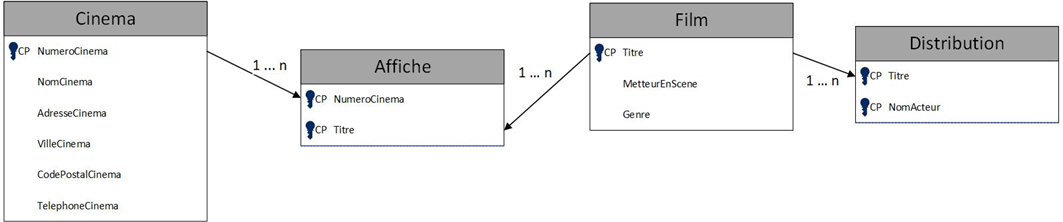

**Exemple:**

In [ ]:
# Chargement de la bibliothèque sql permettant d'utiliser des requêtes du langage SQL dans ce notebook Jupyter
%load_ext sql

In [ ]:
import urllib.request
import sqlite3

DB_URL = "https://raw.githubusercontent.com/ptsireunion/BDD/main/cinemas.db"
DB_NAME = "cinemas.db"

urllib.request.urlretrieve(DB_URL, DB_NAME)

conn = sqlite3.connect(DB_NAME)

print("Base prête")

In [ ]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'
# Chargement de la base de données "cinemas"
%sql sqlite:///cinemas.db

In [ ]:
%sql SELECT * FROM cinema

In [ ]:
%sql SELECT NomCinema FROM cinema WHERE VilleCinema = 'Besancon'

**Q1. Prenez le temps de la reflexion puis décrivez et analysez le résultat de cette requête qui utilise la clause WHERE**

## 1.2 Expression des critères de sélection 

Il est possible d'exprimer des critères de sélection plus complexes, en utilisant :
- des opérateurs de comparaison : <, >, >=, <=, =, <>
- des opérateurs logiques : AND, OR, NOT, XOR(`HP`)
- d'autres prédicats qui servent à devenir des ensembles (`HP`) : IN, BETWEEN ... AND ..., LIKE
- la comparaison avec la valeur NULL (`HP`): IS NULL, IS NOT NULL

In [ ]:
%sql SELECT NomCinema FROM cinema WHERE VilleCinema = 'Besancon' OR VilleCinema = 'Paris'

In [ ]:
%sql SELECT NomCinema FROM cinema WHERE VilleCinema IN ('Besancon','Paris')

On obtient le même résultat. L'avantage de la clause IN est une écriture plus compacte et plus lisible. Mais `HP`

## 1.3. Quelques requêtes à écrire 

Rappel du contenu des tables de la base de données cinemas:

In [ ]:
%sql SELECT * FROM DISTRIBUTION 

In [ ]:
%sql SELECT * FROM affiche

In [ ]:
%sql SELECT * FROM film

**Q2. Ecrire les requêtes suivantes en SQL en utilisant la clause WHERE**

a. Les acteurs jouant dans Alerte

In [ ]:
%sql SELECT NomActeur FROM distribution WHERE titre='Alerte'

b. Les titres des films à l'affiche du cinéma numéro 1

In [ ]:
%sql SELECT titre FROM affiche WHERE NumeroCinema='1' 

c. Les titres des films mis en scène par Téchiné


In [ ]:
%sql SELECT titre FROM film WHERE MetteurEnScene='Techine'

d. Les films d'aventure ou mis en scène par Téchiné


In [ ]:
%sql SELECT titre FROM film WHERE MetteurEnScene='Techine' OR Genre='Aventure'

e. Les informations sur les films ayant Balasko comme metteur en scène et qui sont des
comédies.


In [ ]:
%sql SELECT * FROM film WHERE MetteurEnScene='Balasko' AND Genre='Comedie'

f. Le nom des acteurs qui commencent par "D".


Pour la requête attendue, le critère de sélection peut faire appel à l'opérateur **LIKE** qui signifie que le nom de l'acteur doit avoir la même forme que la chaîne de caractères qui suit ce terme. Ici, il faut que la 1ère lettre du nom d'un acteur commence par la lettre D et qui se poursuit par n'importe quelle chaîne de caractères: cela s'écrit **D%**.

In [ ]:
%sql SELECT NomActeur FROM distribution WHERE NomActeur LIKE 'D%'

g. Le titre des films qui sont des comédies dramatiques et qui ont un metteur en scène dont le nom commence par "T".

In [ ]:
%sql SELECT titre FROM film WHERE Genre='Comedie Dramatique' AND MetteurEnScene LIKE 'T%' 

h. Le nom des cinémas dont le code postal est compris entre 25000(inclus) et 25999(inclus).

In [ ]:
%sql SELECT NomCinema FROM cinema WHERE 25000<=CodePostalCinema AND CodePostalCinema<=25999

Essayez avec la requête **BETWEEN...AND...**

In [ ]:
%sql SELECT NomCinema FROM cinema WHERE CodePostalCinema BETWEEN 25000 AND 25999

# 2 Les opérateurs ensemblistes

## 2.1 Introduction

Trois opérateurs ensemblistes permettent de combiner des sélections. Ces opérateurs sont: l'union, l'intersection et la différence. 

Pour chacun des ces opérateurs, la syntaxe est la même. Ils permettent de composer le résultat de deux requêtes SELECT.

SELECT ...

OPERATEUR ENSEMBLISTE

SELECT ...

Les deux requêtes doivent retourner des relations ayant le même en-tête.

## 2.2 L'opérateur UNION

Exemple

In [ ]:
%sql SELECT NomCinema FROM CINEMA WHERE VilleCinema = 'Besancon' UNION SELECT NomCinema FROM CINEMA WHERE VilleCinema ='Paris'

**Q3. Décrivez le résultat de la requête précédente utilisant l'opérateur UNION**

## 2.3 L'opérateur INTERSECT

In [ ]:
%sql SELECT NomCinema FROM CINEMA WHERE VilleCinema = 'Besancon' INTERSECT SELECT NomCinema FROM CINEMA \
WHERE VilleCinema = 'Paris'
# le symbole '\' permet d'écrire le code sur plusieurs lignes. A l'écrit il faudra juste changer de ligne à chaque nouvelle clause...

**Q4. Décrivez le résultat de la requête précédente utilisant l'opérateur INTERSECT**

# 2.4 L'opérateur EXCEPT (différence)

In [ ]:
%sql SELECT NomCinema FROM CINEMA WHERE VilleCinema = 'Besancon' EXCEPT SELECT NomCinema FROM CINEMA WHERE VilleCinema ='Paris'

In [ ]:
%sql SELECT NomCinema FROM CINEMA WHERE VilleCinema = 'Paris' EXCEPT SELECT NomCinema FROM CINEMA WHERE VilleCinema ='Besancon'

**Q5. Décrivez le résultat de la requête précédente utilisant l'opérateur EXCEPT**

Vous écrirez quelques requêtes en utilisant ces opérateurs plus tard lorsque les jointures seront présentées.

# 3. Complément sur les règles d'intégrité

## 3.1 Préambule 

Nous avions vu dans le TP1 qu'une base de données devait respecter un certain nombre de règles d'intégrité pour son bon fonctionnement:

1. Unicité de clé
2. les contraintes de domaine, qui permettent de vérifier l'intégrité des attributs,
3. la règle d'intégrité des entités qui permet de préciser quelles valeurs doivent obligatoirement être définies,
4. et enfin les contraintes de références, qui font appel aux notions de clés étrangères et qui permettent de vérifier la cohérence des informations entre différentes relations.

Ce paragraphe 3 traite de la dernière règle concernant les contraintes de référence

## 3.2 Les clés étrangères

Depuis le TP1, vous aviez remarqué que certains attributs ou ensembles d'attributs pouvaient apparaître dans plusieurs relations. Nous définissons ici cette "liaison" entre ces différentes relations.

Reprenons le modèle relationnel de la base de données cinemas et intéressons nous aux 2 relations cinema et affiche ainsi qu'au lien visible entre elles

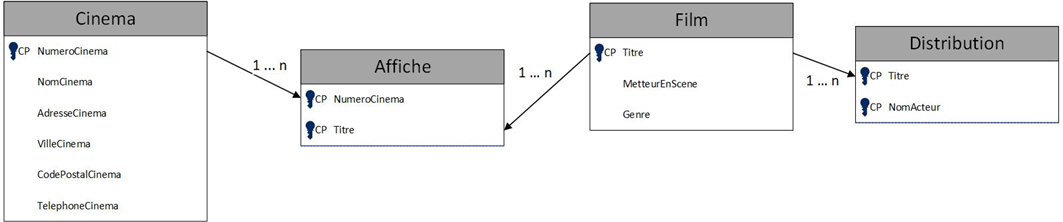

Remarquons que l'attribut "NumeroCinema" est clé primaire de la relation Cinema mais pas de la relation Affiche puisque la clé primaire de cette dernière relation est le couple (NumeroCinema, Titre). Ceci étant dit, l'attribut NumeroCinema existe dans les 2 relations cinema et affiche. 

On dit que l'attribut NumeroCinema est clé étrangère de la relation affiche. Les valeurs des 2 attributs sont naturellement identiques. 

On trace un lien qui va de la relation où l'attribut est clé primaire vers la relation où ce même attribut est clé étrangère. 

**On peut généraliser ce constat par la définition suivante:**

Soit R une relation, une clé étrangère dans R est un sous-ensemble C, de l'ensemble des attributs
de R, tel que :
- Il existe une relation R' avec une clé primaire C', et 
- à tout instant, chaque valeur de C dans la relation R, est identique à une valeur de C' dans la relation R'.

On dit aussi que l'on définit un lien entre les relations R' et R.


## 3.3 Les liens entre relations

On a l'habitude de représenter un tel lien entre 2 relations au moyen d'une flèche allant de la clé primaire vers la clé étrangère, comme le montre la figure ci-après:

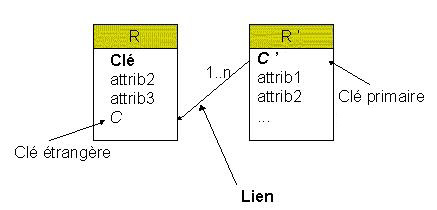

Un lien entre deux relations, peut être de différents types, selon le nombre de fois ou la valeur de la clé primaire de la relation source peut apparaître en tant que clé étrangère dans la relation
cible (ce que nous avons représenté ci-dessus par (? .. ?)).

 On définit deux types de liens :
 
- Lien 1..n : une valeur de la clé primaire peut apparaître 0 à n fois en tant que clé étrangère.
- Lien 1..1 : une valeur de la clé primaire ne peut apparaître qu'une et une seule fois en tant que clé étrangère.

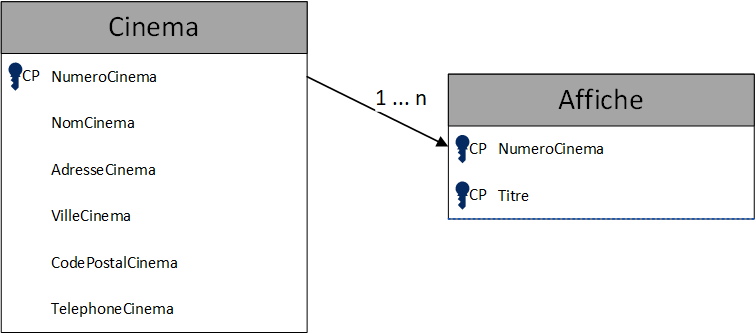

Dans l'exemple du lien entre les 2 relations cinema et affiche, vous pouvez remarquer que le lien est de type 1..n. NumeroCinema est la clé primaire de la relation CINEMA, et la clé étrangère de la relation AFFICHE

Cela signifie que: 

- Tout t-uplet introduit dans la relation AFFICHE doit faire référence à un cinéma qui existe (présence d'un t-uplet dans la relation CINEMA avec la même valeur pour l'attribut NumeroCinema).
- De plus le lien est de type (1..n) car un cinéma peut apparaître plusieurs fois dans la relation AFFICHE. Ce qui signifie qu'il peut y avoir plusieurs films à l'affiche d'un même cinéma et qu'un même numéro de cinéma peut apparaitre 0 ou plusieurs fois dans la relation affiche.

Considérons maintenant le lien entre les relations film et affiche 

**Q6. Après avoir identifié l'attribut jouant le rôle de clé primaire et celui de clé étrangère, décrire comme dans l'exemple précédent, le lien existant entre ces 2 relations. Quelle indication permet de comprendre qu'un film peut être à l'affiche de plusieurs cinémas?**

Considérons maintenant le lien entre les relations film et distribution 

**Q7. Que dire de ce lien?**

## 3.4 Les contraintes de référence

Les contraintes référentielles permettent au SGBD de gérer automatiquement la présence de données référencées dans différentes relations de la base.

Toujours en s'appuyant sur la base de données cinémas, on peut constater que dans la relation DISTRIBUTION, l'attribut Titre fait référence au film dans lequel joue l'acteur. Ainsi le t-uplet ("Junior", "Schwarzenegger"), signifie que l'acteur Schwarzenegger joue dans le film Junior. 

La valeur prise par l'attribut Titre ne peut être qu'une valeur apparaissant dans la relation FILM. En effet, il ne serait pas cohérent de décrire la distribution d'un film qui n'existe pas.

On associe à la notion de clé étrangère, la règle suivante qui permet de conserver un ensemble de données cohérent dans la base de données.

**L'intégrité référentielle **: La base de données ne doit pas contenir de valeurs de clés étrangères non unifiables.

Ceci signifie que si une clé étrangère prend une valeur alors cette valeur existe dans la relation référencée par le lien.

Dans l'exemple du lien entre les relations film et distribution, ceci signifie qu'il ne peut exister dans la relation DISTRIBUTION de t-uplet (Zorro, acteur) si dans la table FILM, il n'existe pas de t-uplet (Zorro, ...).

# 4. Les jointures

## 4.1. Définition théorique

Nous avions vu dans le paragraphe 1 la manipulation des données en utilisant l'ordre FROM et la clause WHERE. Remarquez que vous n'utilisiez à chaque fois qu'une et une seule relation. 

Comment réaliser une manipulation de données à partir de 2 relations distinctes d'une même base de données ? En utilisant par exemple un critère de sélection entre 2 attributs issus de 2 relations distinctes.

L'opérateur de jointure permet de répondre à cette question.

**Une jointure consiste à construire une nouvelle relation dont les t-uplets sont la concaténation d'un t-uplet d'une relation 1, et d'un t-uplet d'une relation 2 vérifiant une condition dite de jointure.**

La jointure peut être vue comme un produit cartésien suivi d'une sélection ayant comme condition, la condition de jointure.

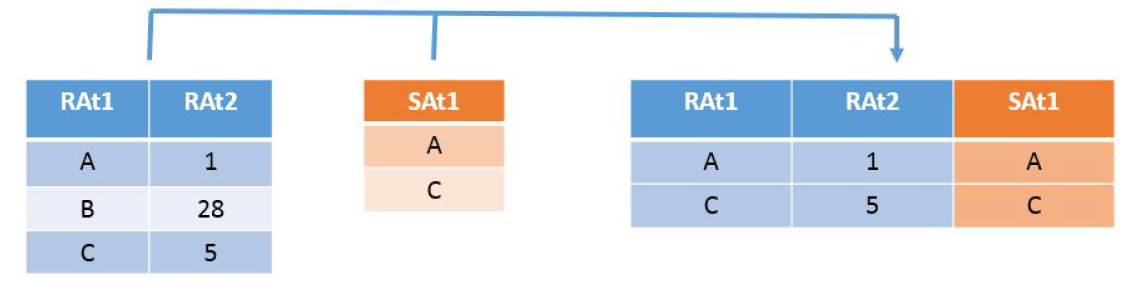


Ici, les relations R et S sont concaténées (produit cartésien) de manière à construire la nouvelle relation T qui ne gardera que les t-uplets respectant la condition de jointure: ici, les valeurs communes des attributs RAt1 et SAt1

## 4.2. Implémentation dans le langage SQL 

En reprenant la base de données cinemas, on souhaite par exemple donner pour chaque cinéma la liste des films qui sont à l'affiche.

In [ ]:
%sql SELECT * FROM cinema

In [ ]:
%sql SELECT * FROM affiche

On voit bien que pour ces 2 relations, l'attributs commun est NumeroCinema, clé primaire de la relation cinema. Elle est clé étrangère dans la relation affiche. L'intégrité référentielle est respectée.

Pour afficher les films à l'affiche de chaque cinéma (référencé par son nom), il est nécessaire de réaliser une jointure entre les 2 relations en question. On imposera comme condition de jointure cinema.NumeroCinema = affiche.NumeroCinema

Il y a 2 manières d'implémenter cela dans SQL

### 4.2.1  Expression de la jointure avec la clause WHERE

On peut réaliser un produit cartésien entre les 2 relations cinema et titre comme utilisé dans le TP1 puis imposer la condition de jointure cinema.NumeroCinema = affiche.NumeroCinema dans une clause WHERE comme ci-après:

In [ ]:
%sql SELECT * FROM cinema, affiche WHERE cinema.NumeroCinema = affiche.NumeroCinema

In [ ]:
%sql SELECT * FROM cinema, affiche

Comme expliqué dans le paralgraphe précédent, l'opération a réalisé la concaténation des attributs de la relation cinema avec les attributs de la relation affiche en gardant uniquement les t-uplets commun des attributs NumeroCinema.

A partir de là, nous pouvons demander à afficher directement uniquement le nom des cinémas et les titres à l'affiche:

In [ ]:
%sql SELECT NomCinema, Titre FROM cinema, affiche WHERE cinema.NumeroCinema = affiche.NumeroCinema

autre possibilité :

In [ ]:
%sql SELECT cinema.NomCinema, affiche.Titre FROM cinema, affiche WHERE cinema.NumeroCinema = affiche.NumeroCinema

## 4.2.2 Expression de la jointure avec l'opérateur JOIN 

Cette autre possibilité de réaliser une jointure permet d'aborder des jointures plus complexes... Celle proposée ici réalise la même chose que l'utilisation de la clause WHERE. L'opérateur JOIN est à connaitre en cas d'analyse de requêtes imposées dans un sujet.

In [ ]:
%sql SELECT cinema.NomCinema, affiche.Titre FROM cinema JOIN affiche ON cinema.NumeroCinema = affiche.NumeroCinema

Le résultat de cette requête est identique à la requête précédente.

La structure de la requête est la suivante:    **SELECT * FROM R JOIN S ON Condition de jointure**. R et S sont 2 relations distinctes.

## 4.3 À vous de vous entrainer ! 

**Q8. Décrire en SQL la requête suivante (en utilisant les deux façons de traduire une jointure) : Le nom des cinémas ayant au moins un film à l'affiche.**

In [ ]:
%sql SELECT DISTINCT cinema.NomCinema FROM cinema JOIN affiche ON cinema.NumeroCinema=affiche.NumeroCinema

In [ ]:
%sql SELECT DISTINCT cinema.NomCinema FROM cinema,affiche WHERE cinema.NumeroCinema=affiche.NumeroCinema

**Q9. Décrire en SQL la requête suivante en utilisant les deux façons de traduire une jointure: Les titres des films à l'affiche du Vox.**

In [ ]:
%sql select DISTINCT titre FROM affiche JOIN cinema ON affiche.NumeroCinema='1'

In [ ]:
%sql SELECT Titre FROM affiche,cinema WHERE cinema.NumeroCinema=affiche.NumeroCinema AND NomCinema='Vox' 

**Q10. Décrire en SQL la requête suivante en utilisant les deux façons de traduire une jointure: Le nom des cinémas ayant à l'affiche Junior.**

In [ ]:
%sql SELECT NomCinema FROM cinema JOIN affiche ON affiche.NumeroCinema=cinema.NumeroCinema WHERE Titre='Junior'

In [ ]:
%sql SELECT NomCinema FROM cinema,affiche WHERE affiche.NumeroCinema=cinema.NumeroCinema AND Titre='Junior'

Pour la suite, si nécessaire, utilisez des opérateurs ensemblistes (vus au paragraphe 2).

**Q11. Décrire en SQL la requête suivante en utilisant les opérateurs ensemblistes: Les noms des acteurs des films mis en scène par Téchiné ou Peterson.**

In [ ]:
%sql SELECT NomActeur FROM distribution JOIN film ON distribution.Titre=film.Titre WHERE MetteurEnScene='Techine' OR  MetteurEnScene='Peterson'

**Q12. Décrire en SQL la requête suivante en utilisant les opérateurs ensemblistes: Les titres des films à l'affiche du cinéma Vox ET EN MÊME TEMPS du cinéma Numéro 3.**

In [ ]:
%sql SELECT Titre FROM affiche WHERE NumeroCinema=3 INTERSECT SELECT Titre FROM affiche JOIN cinema ON cinema.NumeroCinema=affiche.NumeroCinema WHERE NomCinema='Vox'

In [ ]:
%sql SELECT NomActeur FROM distribution

**Q13. Décrire en SQL la requête suivante en utilisant les opérateurs ensemblistes: Les noms des acteurs qui n'ont jamais joué dans un film mis en scène par Reitman**

In [ ]:
%sql SELECT NomActeur FROM distribution EXCEPT SELECT NomActeur FROM distribution JOIN film ON distribution.Titre=film.Titre WHERE MetteurEnScene='Reitman'

<h1><center>FIN TP2</center></h1>